# BÀI TẬP: TITANIC
**Nguồn:** kaggle.com/c/titanic (891 dòng)


In [22]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [25]:
# TODO
print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")
print(f"Tên cột: {df.columns.tolist()}")
print("Kiểu dữ liệu:")
df.info()

Số dòng: 891, Số cột: 15
Tên cột: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool  

## A.2. Missing values & Duplicate data

In [26]:
# TODO
missing = df.isnull().sum()
print(f"Số dòng thiếu dữ liệu:")
print(missing[missing>0] if missing.sum()>0 else "Không có cột nào thiếu dữ liệu")

print("Số lượng dữ liệu trùng:", df.duplicated().sum())
df = df.drop_duplicates()
print("Số lượng dữ liệu trùng sau khi drop:", df.duplicated().sum())

Số dòng thiếu dữ liệu:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64
Số lượng dữ liệu trùng: 107
Số lượng dữ liệu trùng sau khi drop: 0


## A.3. Invalid values

In [27]:
# TODO
print("Tuổi <0: ", (df['age']<0).sum())
print(df['pclass'].value_counts())
print(df['class'].value_counts())
print("------------------------")
print(df['alive'].value_counts())
print(df['survived'].value_counts())

Tuổi <0:  0
pclass
3    405
1    214
2    165
Name: count, dtype: int64
class
Third     405
First     214
Second    165
Name: count, dtype: int64
------------------------
alive
no     461
yes    323
Name: count, dtype: int64
survived
0    461
1    323
Name: count, dtype: int64


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [56]:
# TODO
df['family_size'] = df['sibsp'] + df['parch'] +1
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False,6
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [57]:
# TODO
for col in ['age', 'fare']:
    s = df[col]
    mean_, median_, mode_ = s.mean(), s.median(), s.mode()[0]
    print(f"---{col}---")
    print(f"Mean= {mean_}, Median= {median_}, Mode= {mode_}")
    

---age---
Mean= 29.869351032448375, Median= 28.25, Mode= 24.0
---fare---
Mean= 34.71173966836735, Median= 15.9, Mode= 13.0


## Group 2 — Dispersion

In [58]:
# TODO
for col in ['age', 'fare']:
    s = df[col]
    range_= s.max()- s.min()
    std_= s.std()
    q1, q3= s.quantile([.25, .75])
    iqr= q3-q1
    cv= std_/s.mean()*100
    print(f"---{col}---")
    print(f"Range= {range_}, Std= {std_}, IQR= {iqr}, CV= {cv}")

---age---
Range= 79.58, Std= 14.759076476056258, IQR= 19.0, CV= 49.41210962375055
---fare---
Range= 512.3292, Std= 52.16015119818791, IQR= 26.05935, CV= 150.26660056949325


## Group 3 — Location and Shape

---age---
P25=20.00, P50=28.25, P75=39.00
Skew= 0.36664075763856613, Kurtosis= 0.08122315547053738
---fare---
P25=8.05, P50=15.90, P75=34.11
Skew= 4.56201871611229, Kurtosis= 30.008098670029952


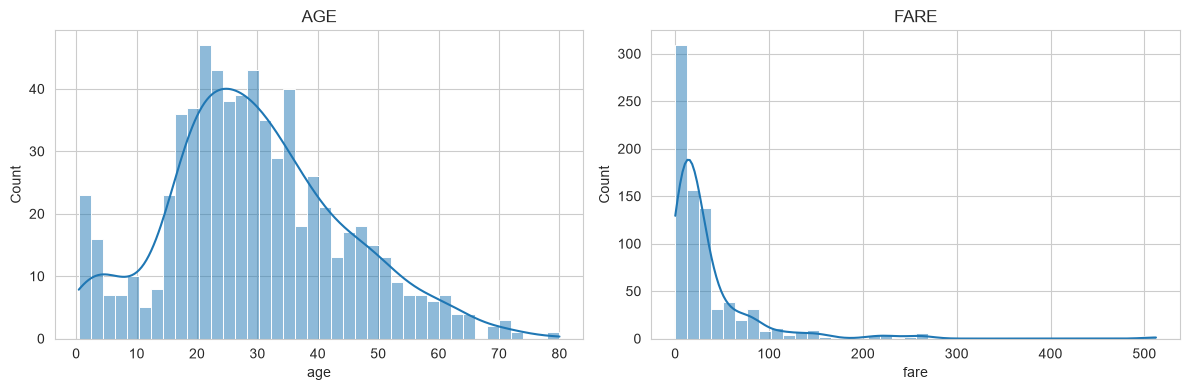

Nhận xét: 75% khách hàng có tuổi <=39 chủ yếu là từ 20-40 tuổi, đồ thị tuổi lệch phải ít, độ tuổi phân bố tương đối đều, kurtosis thấp -> không có dấu hiệu có giá trị cực đoan
Nhận xét: giá vé lệch phải mạnh -> phần lớn khách hàng mua giá vé thấp trong khi một số khách hàng có giá vé rất cao. kurtosis rất nặng -> có giá trị cực đoan cao


In [59]:
# TODO
for col in ['age', 'fare']:
    s = df[col].dropna()
    skew_, kurtosis_= stats.skew(s), stats.kurtosis(s)
    print(f"---{col}---")
    print(f"P25={s.quantile(.25):.2f}, P50={s.quantile(.50):.2f}, P75={s.quantile(.75):.2f}")
    print(f"Skew= {skew_}, Kurtosis= {kurtosis_}")
    # dropna để có thể tính skew, kurtosis



fig, axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['age'], bins=40, kde=True, ax=axes[0]); axes[0].set_title('AGE')
sns.histplot(df['fare'], bins=40, kde=True, ax=axes[1]); axes[1].set_title('FARE')
plt.tight_layout(); plt.show()

print("Nhận xét: 75% khách hàng có tuổi <=39 chủ yếu là từ 20-40 tuổi, đồ thị tuổi lệch phải ít, độ tuổi phân bố tương đối đều, kurtosis thấp -> không có dấu hiệu có giá trị cực đoan")
print("Nhận xét: giá vé lệch phải mạnh -> phần lớn khách hàng mua giá vé thấp trong khi một số khách hàng có giá vé rất cao. kurtosis rất nặng -> có giá trị cực đoan cao")



---
PHẦN C — DEFINE THE QUESTION

Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [60]:
# TODO
perc = df.groupby('pclass')['survived'].mean()*100
print(perc)
print(f"Hạng vé 1 có tỷ lệ sống sót cao nhất, chênh lệch {(perc.max()- perc.min()).round(2)}% so với hạng vé thấp nhất")

pclass
1    63.084112
2    50.909091
3    25.679012
Name: survived, dtype: float64
Hạng vé 1 có tỷ lệ sống sót cao nhất, chênh lệch 37.41% so với hạng vé thấp nhất


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [ ]:
# TODO
print(df.groupby(['sex', 'pclass'])['survived'].mean() *100)

print("Nhận xét: Giới tính ảnh hưởng tới tỷ lệ sống sót mạnh hơn. Hạng vé cũng ảnh hưởng tới tỷ lệ sống sót nhưng không nhiều bằng giới tính. Ở dây nữ có tỉ lệ sống sót ở các hang vé đều cao hơn nam")

sex     pclass
female  1         96.774194
        2         91.780822
        3         47.244094
male    1         37.190083
        2         18.478261
        3         15.827338
Name: survived, dtype: float64
Nhận xét: Giới tính ảnh hưởng tới tỷ lệ sống sót mạnh hơn. Ở dây nữ có tỉ lệ sống sót ở các hang vé đều cao hơn nam


## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

In [62]:
# TODO
print(df.groupby('pclass')['survived'].mean()*100)
print("Nhận xét: Giá vé đắt hơn ảnh hưởng tới tỷ lê sống sót. ở đây vé hạng 1 tỷ lệ sống sót cao nhất 65%, tiếp đến là vé hạng 2 với 50% tỷ lệ sống sót. Vé hạng 3 có ỷ lệ sống sót rất thấp chỉ 25% ")

pclass
1    63.084112
2    50.909091
3    25.679012
Name: survived, dtype: float64
Nhận xét: Giá vé đắt hơn ảnh hưởng tới tỷ lê sống sót. ở đây vé hạng 1 tỷ lệ sống sót cao nhất 65%, tiếp đến là vé hạng 2 với 50% tỷ lệ sống sót. Vé hạng 3 có ỷ lệ sống sót rất thấp chỉ 25% 


## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [73]:
# TODO
print(df.groupby('family_size')['survived'].mean()*100)
print("Nhận sét: Gia đình đông người có ảnh hưởng đến tỷ lệ sống sót. Gia đình từ 2-4 người có tỷ lệ sống sót rất cao nhưng khi số người trong gia đình từ 5 trở lên thì tỷ lệ sống sót càng giảm rõ rệt")

family_size
1     33.632287
2     55.194805
3     57.425743
4     71.428571
5     23.076923
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: survived, dtype: float64
Nhận sét: Gia đình đông người có ảnh hưởng đến tỷ lệ sống sót. Gia đình từ 2-4 người có tỷ lệ sống sót rất cao nhưng khi số người trong gia đình từ 5 trở lên thì tỷ lệ sống sót càng giảm rõ rệt


## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [75]:
# TODO
p = (df.groupby('embark_town')['survived'].mean()*100).sort_values(ascending=False)
print(f"Cảng lên tàu {p.idxmax()} có tỷ lệ sống sót cao nhất {p.max():.2f}%")

Cảng lên tàu Cherbourg có tỷ lệ sống sót cao nhất 58.06%


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

Insight:

Thiếu rất nhiều dòng dữ liệu về age, deck và có tới 107 dòng trùng lặp.

Độ tuổi trung bình là 29, số tuổi nhiều nhất là 24. Khoảng cách người có tuổi thấp nhất so với người có tuổi cao nhất là 79. Dữ liệu giao động 50% xoay quanh mean.
Đồ thị tuổi lệch phải nhẹ, độ tuổi phân bố tương đối đều không có dấu hiệu giá trị cực đoan.

Giá vé trung bình là 34$, số vé bán nhiều nhất là 13$. Dữ liệu giao động cao, 150% xoay quanh mean. Đồ thị giá vé lệch phải mạnh, kurtosis rất cao -> có giá trị cực đoan cao.

Mỗi hạng vé đều có tỉ lệ sống sót khác nhau nhưng giới tính ảnh hưởng tới tỷ lệ sống sót nhiều hơm. Nữ có tỷ lệ sống sót cao hơn nam rất nhiều dù cùng chung hạng vé.

Giá vé có ảnh hưởng tới tỷ lệ sống sót, vé càng đắt tỷ lệ sống sót càng cao.

Số lượng thành viên trong gia đình ảnh hưởng tới tỷ lệ sống sót, gia đình từ 2-4 người có tỷ lệ sống sót cao còn từ 5 người trở lên thì tỷ lệ sống sót giảm dần.

Cảng Cherbourg có tỷ lệ sống sót cao nhất 58.06%


